In [1]:
fn = 'dev'
run_type = 'E'
# seed = 3

# loo = True

# defaults
bn_weights_lambda_L2 = 1e-7
uniform_lambda_L2 = 1e-7
cat_max_norm = 100
global_bias_lambda_L2 = 0
cat_bias_lambda_L2 = 0
vae_scaling_KL = 1e-2
global_bias_lambda_L1 = 0
cat_bias_lambda_L1 = 0
vae_prior_mu = 0
vae_prior_sigma = 1
adj_scaling_KL = 0
adj_prior_mu = 0
adj_prior_sigma = 0.2
cat_bias_orthogonality_scaler = 0
cat_b_adv = 1.5

In [2]:
run_types = {'A': (1, True),
            'B': (3, True), 
            'C': (7, True), 
            'D': (10, True), 
            'E': (1, False)
            }
seed, loo = run_types[run_type]

In [3]:
visualize = False
mod_type = 'default'
subset = True
short_run = True
seed_split = 888

In [4]:
n_fraction = 0.2

train_frac, test_frac = 0.8, 0.2

a_scale = 10
b_scale = 2

# if mod_type not in ['default', 'tot_bias_scaler', 'global_bias_scaler', 'mu_bias_scaler', 
#                    'global_bias_regularizer', 'mu_bias_regularizer', 
#                    'standardized_weights']:
#     raise ValueError('Incorrect mod type specified')

# # assign file name accordingly

# fn = mod_type
# if mod_type == 'tot_bias_scaler':
#     fn += '_tot_a' + str(a_scale) + '_b' + str(b_scale)
# elif mod_type == 'global_bias_scaler':
#     fn += '_global_a' + str(a_scale) + '_b' + str(b_scale)
# elif mod_type == 'mu_bias_scaler':
#     fn += '_mu_a' + str(a_scale) + '_b' + str(b_scale)
# if subset:
#     fn += '_subset'
# if short_run:
#     fn += '_short_run'
# if loo:
#     fn += '_loo'



In [5]:
import os
from typing import Optional, Dict, List, Literal
import copy
import itertools
from tqdm import tqdm
import gc
import math

import pandas as pd
import numpy as np
import scanpy as sc

from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
import torch
import scanpy as sc
import pandas as pd
from typing import List, Literal
import torch
from geomloss import SamplesLoss
import torch.nn as nn

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.model_selection import train_test_split


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [6]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

# from scLEMBAS.model.train_dev_mu_regularizer import TrainSC as TrainSCDevMu
# from scLEMBAS.model.train_dev_weights_standard import TrainSC as TrainSCDevWstandard
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, embed_tf_activity, get_alignment_score


# from scLEMBAS.model.scl_dev_tot_scaler import SignalingModel as SignalingModelDevTot
# from scLEMBAS.model.scl_dev_global_scaler import SignalingModel as SignalingModelDevGlobal
# from scLEMBAS.model.scl_dev_mu_scaler import SignalingModel as SignalingModelDevMu
# from scLEMBAS.model.scl_dev_weights_standard import SignalingModel as SignalingModelDevWstandard
from scLEMBAS.model.scl import SignalingModel

SM = {'default': SignalingModel}#, 
#      'tot_bias_scaler': SignalingModelDevTot, 
#      'global_bias_scaler': SignalingModelDevGlobal, 
#      'mu_bias_scaler': SignalingModelDevMu, 
#      'global_bias_regularizer': SignalingModel, 
#      'mu_bias_regularizer': SignalingModel,
#      'standardized_weights': SignalingModelDevWstandard # initializes weights much larger
#      }

TR = {'default': TrainSC}#, 
#      'tot_bias_scaler': TrainSC, 
#      'global_bias_scaler': TrainSC, 
#      'mu_bias_scaler': TrainSC, 
#      'global_bias_regularizer': TrainSC, # by default, regularizes global bias
#       'mu_bias_regularizer': TrainSCDevMu, 
#       'standardized_weights': TrainSCDevWstandard 
#      }

sys.path.insert(1, '/home/hmbaghda/Projects/scLEMBAS/notebooks/Kang_2017/')
from Kang_utils import (rev_stim, stim_map, rev_stim_map, adata_dimviz_bias, clear_memory,
                        get_prediction, adata_dimviz_prediction, prepare_for_metrics, get_loss)

In [7]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'id_expr_scored.h5ad'))

tf_adata = tf_adata[adata.obs_names,:]
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

# mouse naming convention
tf_adata.obs['sample'] = tf_adata.obs['sample'].apply(lambda l: (l[0] + l[1:].lower()).replace('-', ''))

sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'ID_input_network.csv'), index_col = 0)
tf_adata.obs['condition'] = tf_adata.obs['sample'].astype(str) + '^' + tf_adata.obs['celltype'].astype(str)


source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

/tmp/ipykernel_547176/3951140449.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tf_adata.obs['sample'] = tf_adata.obs['sample'].apply(lambda l: (l[0] + l[1:].lower()).replace('-', ''))


# 1. Create a novel train-test split:

In [9]:
def ood_split(tf_adata, 
             train_frac: float, 
              stim_col: str = 'stim', 
              context_col: str = 'seurat_annotations', 
              context_bins: Optional[pd.DataFrame] = None, 
              context_bins_frac: float = 1, 
             max_iter: int = 1000, 
             seed: int = 888, 
             deviation_thresh: float = 0.025, 
             include_train_cond: Optional[Dict[str, List]] = None):
    """Generate an OOD train test split, where both the condition data and the single-cells have approximately
    the specified split.
    
    Rules: 
    1. cell split and condition split is similar (conditions is exactly the split, 
    cells is approximate by deviation_thresh)
    2. Each component (condition_cols) of the condition is seen atleast once in the training
    3. Each of the stimulation column is seen atleast once in the test
    4. The test context (cell type) needs to contain atleast one from context_frac of the total context_bins 

    Parameters
    ----------
    tf_adata : 
        AnnData object of TF activity
    train_frac : float
        the fraction of the data going to training
    stim_col : List[str]
        the metadata column defining the stimulation condition
    context_col: str
        the metadata column of the context, together with stim col defines the OOD split
    context_bins: Optional[pd.DataFrame]
        binning of the context categories, by default None
    context_bins_frac: float
        the number of bins that should be included in the test data from the context bins
    max_iter : int, optional
        total iterations to try to identify a suitable split, by default 1000
    seed : int, optional
        random state variable, by default 888
    deviation_thresh : float, optional
        extent to which to allow the single-cell split to deviate from the specified `train_frac split`, by default 0.025
    include_train_cond : Optional[Dict[str, List]]
        a dictionary with keys for each of stim_col and context_col and keys as a list that represents a subset
        of values in that column that must be included in the training set. 
    """
    test_frac = 1 - train_frac

    condition_cols = [stim_col, context_col]
    condition_combs = tf_adata.obs[condition_cols].apply(lambda row: '^'.join(row.astype(str)), axis=1)
    unique_conditions = condition_combs.drop_duplicates(keep = 'first', inplace = False).tolist()

    # define the conditions for stopping
    train_frac_deviation = np.inf
    zero_shot_bool = False

    test_stim = False
    n_stims = tf_adata.obs['sample'].nunique()

    if context_bins is not None:
        if context_bins_frac > 1 or context_bins_frac < 0:
            raise ValueError('The fraction must be between 0 and 1')
        n_contexts = np.floor(context_bins_frac*context_bins.nunique())
        context_present = False
    else:
        context_present = True

    if include_train_cond is not None:
        if sorted(set(include_train_cond).intersection(condition_cols)) != sorted(condition_cols):
            raise ValueError('Keys for `include_train_cond` must be the same as `condition_cols`')
        for cond, cond_vals in include_train_cond.items():
            if not set(cond_vals).issubset(tf_adata.obs[cond].tolist()):
                raise ValueError('The conditions to include in training for ' + cond + ' are not present in the metadata.')
        ict_bool = False
    else:
        ict_bool = True

    counter = 0
    while (train_frac_deviation > deviation_thresh or not zero_shot_bool or not ict_bool or not test_stim or not context_present) and (counter < max_iter):
        # ood at categorical level
        train_cond, test_cond = train_test_split(unique_conditions, test_size = test_frac, random_state = seed + counter, shuffle = True)
        train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
        test_cells = condition_combs[condition_combs.isin(test_cond)].index.tolist()

        train_frac_actual = len(train_cells)/tf_adata.shape[0]
        train_frac_deviation = abs(train_frac_actual - train_frac)

        # ensure that all individual conditions are seen atleast once (it's the combination of conditions that's unique)
        train_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

        test_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

        zero_shots = [len(test_cond_map[cond].difference(train_cond_map[cond])) for cond in condition_cols]    
        zero_shot_bool = all(value == 0 for value in zero_shots)

        test_stim = (len(test_cond_map['sample']) == n_stims)


        if context_bins is not None:
            context_present = context_bins.loc[list(test_cond_map[context_col])].nunique() >= n_contexts

        if include_train_cond is not None:
            ict_conds = [len(include_train_cond[cond].difference(cond_vals)) for cond, cond_vals in train_cond_map.items()]
            ict_bool = any(value == 0 for value in ict_conds)

        counter += 1

    if counter < max_iter:
        return train_cells, test_cells, train_cond, test_cond
    else:
        return None, None, None, None

In [10]:
contingency_table = pd.crosstab(tf_adata.obs['sample'], tf_adata.obs['celltype'], 
                                margins=True, margins_name="Total")
contingency_table = contingency_table.T.sort_values(by = 'Total').T
bins = pd.qcut(contingency_table.T.Total, q = 4, labels = False)


In [11]:
if not loo:
    condition_cols = ['sample', 'celltype']
    train_cells, test_cells, train_cond, test_cond = ood_split(tf_adata,
                                                                       train_frac = 0.8,
                                                                       stim_col = condition_cols[0], 
                                                                       context_col = condition_cols[1], 
                                                                       context_bins = bins, 
                                                                       context_bins_frac = 1, 
                                                                       max_iter = 1000, 
                                                                       seed = seed_split, 
                                                                       deviation_thresh = 0.025, 
                                                                       include_train_cond = None)

    test_conds = test_cond
else:
    unique_conditions = sorted(set(tf_adata.obs.condition))

    if run_type in ['A', 'B']:
        unique_conditions.remove('CTRL^DC')
        unique_conditions.insert(0, 'CTRL^DC')
    elif run_type in ['C', 'D']:
        unique_conditions.remove('STIM^DC')
        unique_conditions.insert(0, 'STIM^DC')  
    
    test_cond = [unique_conditions[0]]
    train_cond = sorted(set(unique_conditions).difference(test_cond))
    
    test_conds = test_cond
    
    test_cells = tf_adata.obs[tf_adata.obs.condition.isin(test_cond)].index.tolist()
    train_cells = tf_adata.obs[tf_adata.obs.condition.isin(train_cond)].index.tolist()

In [12]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
Il17b^Neutrophil      1
Il1ra^Neutrophil      1
Scf^Monocyte          1
Vegf^Monocyte         2
Il17b^Monocyte        2
                   ... 
Il27^T_cell_gd      100
Cd27l^Macrophage    100
Hgf^B_cell          100
Ifnk^NK_cell        100
Gdnf^T_cell_CD4     100
Name: count, Length: 1044, dtype: int64

In [13]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
Hgf^Monocyte          2
Igfi^Monocyte         2
Cd30l^Neutrophil      2
Il19^Monocyte         3
Decorin^Monocyte      4
                   ... 
April^Treg          100
Ifnl2^pDC           100
Il23^T_cell_CD8     100
Flt3l^T_cell_CD8    100
Ox40l^Macrophage    100
Name: count, Length: 261, dtype: int64

# 2. Subset data

In [14]:
n_fraction = 0.05

In [15]:
tf_adata.shape[0]*0.05

4743.55

In [16]:
if subset:
    adata_all = adata.copy()
    tf_adata_all = tf_adata.copy()
    train_cells_all = copy.deepcopy(train_cells)

    tf_adata_train = tf_adata_all[train_cells_all, :]
    condition_proportions = tf_adata_train.obs['condition'].value_counts(normalize=True)
    total_cells = tf_adata_train.n_obs
    n_subset = int(n_fraction * total_cells)

    # number of cells to sample per condition
    sample_sizes = (condition_proportions * n_subset).round().astype(int)

    # Subset the cells for each condition
    subset_indices = []
    for condition, n_cells in sample_sizes.items():
        condition_indices = tf_adata_train.obs[tf_adata_train.obs['condition'] == condition].index
        np.random.seed(seed_split)
        sampled_condition_indices = np.random.choice(condition_indices, size=n_cells, replace=False)
        subset_indices.extend(sampled_condition_indices)

    n_train = len(subset_indices)
    train_cells = copy.deepcopy(subset_indices)
    print('The number of train cells has been reduced from {} to {}'.format(tf_adata_train.shape[0], 
                                                                           n_train))

    # include the test data
    subset_indices.extend(test_cells)
    tf_adata = tf_adata_all[subset_indices,:]
    adata = adata_all[subset_indices,:]
    


The number of train cells has been reduced from 76449 to 3807


In [17]:
train_cond = list(set(train_cond).intersection(tf_adata.obs['condition']))

In [18]:
test_conds= list(set(test_conds).intersection(tf_adata.obs['condition']))
test_cond = test_conds

In [19]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
Persephin^eTAC      1
Gitrl^ILC           1
Mcsf^ILC            1
Ifng^Neutrophil     1
Egf^Monocyte        1
                   ..
Vegf^MigDC          5
Il17b^cDC1          5
Light^T_cell_gd     5
Ifnb^T_cell_gd      5
Cd30l^Macrophage    5
Name: count, Length: 933, dtype: int64

In [20]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
Igfi^Monocyte             2
Cd30l^Neutrophil          2
Hgf^Monocyte              2
Il19^Monocyte             3
C3a^Neutrophil            4
                       ... 
April^T_cell_CD4        100
Cd27l^Treg              100
Il5^T_cell_CD4          100
Persephin^T_cell_CD8    100
Rankl^T_cell_CD4        100
Name: count, Length: 261, dtype: int64

# 3. Run training

In [21]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor = 10, lr_decay = 0.9):
    lr_period = 3 if n_epochs < 500 else 4
    lr_params = {'max_epochs': n_epochs, 
                 'maximum_learning_rate': max_lr, 
                 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(n_epochs/lr_period), 
                 'reset_optimizer_epoch': int(n_epochs/3), 
                'lr_decay': lr_decay, 
                 'lr_restart_factor': 1, 
                 'warmup_epochs': int(n_epochs/10)}
    return lr_params

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  lr_scaling_factor = 10, lr_decay = 0.9):
    general_params = generate_lr_params(n_epochs, max_lr, lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay)
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'reset_optimizer_epoch']
    discriminator_params = {'batch_momentum': 0.01,
                            'layer_norm': False,
                            'dropout_rate': 0.1,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [22]:
# hyperparameters
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# linear scaling of inputs/outputs
projection_amplitude_in = 10
projection_amplitude_out = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2}
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}


bionet_params['cat_max_norm'] = cat_max_norm
# if mod_type in ['default', 'total_bias_scaler', 'mu_bias_regularizer', 'mu_bias_scaler']: 
#     bionet_params['cat_max_norm'] = cat_max_norm
# elif mod_type in ['global_bias_scaler', 'global_bias_regularizer']:
#     bionet_params['cat_max_norm'] = 50 # since scaling global bias, need to separately scale categorical with the regularization

    
if mod_type in ['tot_bias_scaler', 'global_bias_scaler', 'mu_bias_scaler']:
    bionet_params['signaling_weights_scaler'] = a_scale
    if mod_type == 'tot_bias_scaler':
        bionet_params['bias_tot_scaler'] = b_scale
    elif mod_type == 'global_bias_scaler':
        bionet_params['bias_global_scaler'] = b_scale
    elif mod_type == 'mu_bias_scaler':
        bionet_params['bias_mu_scaler'] = b_scale

In [23]:
# training parameters
other_params_default = {'network_noise_scale': 10, 'gradient_noise_scale': 1e-9, 
               'test_batch_size': np.nan}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, #50, 
                          'subset_n_spectral': 5} #10}

if mod_type != 'standardized_weights':
    target_spectral_radius = 0.9
else: 
    target_spectral_radius = 30

regularization_params_default = {'input_lambda_L2': 0, # doesn't matter if setting the requires grad to False
                         'bn_weights_lambda_L2': bn_weights_lambda_L2, #1e-7, 
                         'global_bias_lambda_L2': global_bias_lambda_L2, #0, # don't incorporate because of KL divergence
                                 'cat_bias_lambda_L2': cat_bias_lambda_L2,
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e2,  
                         'uniform_lambda_L2': uniform_lambda_L2,#, 1e-7,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 1e-7, 
                        'vae_scaling_KL': vae_scaling_KL, #1e-2
                               'global_bias_lambda_L1': global_bias_lambda_L1, 
                                'cat_bias_lambda_L1': cat_bias_lambda_L1,
                                'vae_prior_mu': vae_prior_mu, 
                                'vae_prior_sigma': vae_prior_sigma, 
                                'adj_scaling_KL': adj_scaling_KL, 
                                 'adj_prior_mu': adj_prior_mu, 
                                 'adj_prior_sigma': adj_prior_sigma, 
                                 'cat_bias_orthogonality_scaler': cat_bias_orthogonality_scaler
                                }


# if mod_type.endswith('_regularizer'):
#     regularization_params_default['bn_weights_lambda_l2'] = 1e-12 # decrease adj matrix regularization
#     regularization_params_default['global_bias_lambda_L2'] = 1e-5 # increase global bias regularization

In [88]:
if not short_run:
    max_penalty_weight = 7.75
#     cat_b_adv = 0.6
    max_epochs = 600
else:
    max_penalty_weight = 8
#     cat_b_adv = 1.5
    max_epochs = 250 
    
    
if subset:
#     batch_factor = 1 if n_fraction <= 0.2 else 3
#     train_batch = int(np.round(n_train/batch_factor))
    batch_factor = 2 if n_fraction <= 0.1 else 3
    train_batch = int(np.round(n_train/batch_factor))
else:
    train_batch = 1024

max_epochs = 10
max_lr = 0.001



cat_discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                          min_penalty_weight = 0.1,
                                                          max_penalty_weight = max_penalty_weight,
                                                          a = 1,
                                                          b = cat_b_adv, 
                                                          curve_type = 'power')

pert_discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                               min_penalty_weight = 0.01,
                                                               max_penalty_weight = 20,
                                                               a = 1,
                                                               b = 2, 
                                                               curve_type = 'power')


lr_params = generate_lr_params(n_epochs = max_epochs, max_lr = max_lr, lr_scaling_factor = 10, lr_decay = 0.9)
cat_discriminator_params = generate_discriminator_params(n_epochs = max_epochs, max_lr = max_lr, 
                      discriminator_penalty_weight = cat_discriminator_penalty_weight, 
                      lr_scaling_factor = 10, lr_decay = 0.9)

pert_discriminator_params = cat_discriminator_params.copy()
pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

regularization_params = regularization_params_default.copy()
other_params = {**other_params_default,
                **{'train_batch_size': train_batch,
                   'validation_batch_size': np.nan}}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}


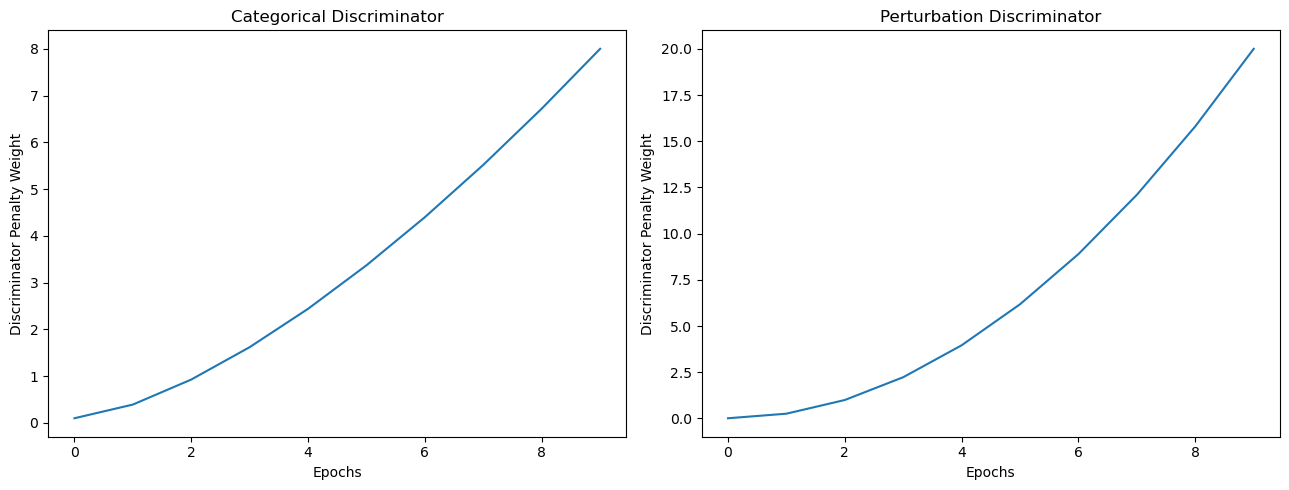

In [89]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();


In [90]:
mod = SM[mod_type](net = sn_ppis,
                 X_in = pd.get_dummies(tf_adata.obs['sample']).astype(int),
                 y_out = tf_adata.to_df().copy(), 
                 expr = adata.to_df().copy(), 
                 covariates = tf_adata.obs.copy(),
                 categorical_covariate_keys = ['celltype'],
                 projection_amplitude_in = projection_amplitude_in, 
                 projection_amplitude_out = projection_amplitude_out,
                 weight_label = weight_label, source_label = source_label, target_label = target_label,
                 bionet_params = bionet_params, 
                 dtype = torch.float32, device = device, seed = seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

In [91]:
trainer = TR[mod_type](mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  cat_discriminator_params = cat_discriminator_params,
                       pert_discriminator_params = pert_discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)

# Start

In [92]:
mod = trainer.train_model(verbose = True)

 10%|████▍                                       | 1/10 [00:01<00:13,  1.51s/it]

i=0, l(tr)=108.05107, s=0.19298, r=0.00010, v=0.00000


100%|███████████████████████████████████████████| 10/10 [00:14<00:00,  1.48s/it]

Training ran in: 0 min 14.77 sec


In [32]:
print('2')

2


# End

# Checkpoint: load the object

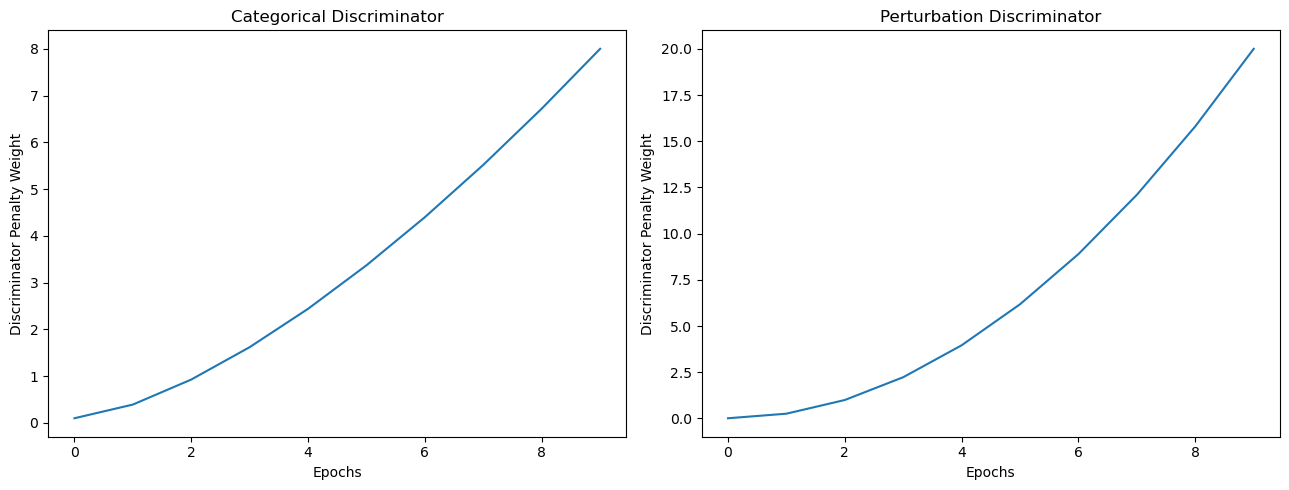

In [93]:
if 'cat_discriminator' not in trainer.__dict__.keys():
    trainer.cat_discriminator = trainer.discriminator

fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(trainer.cat_discriminator['params']['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

if 'pert_discriminator' in trainer.__dict__.keys():
    sns.lineplot(trainer.pert_discriminator['params']['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# 4. Look at the loss curves:

In [94]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

# formatting new/old versions
if 'sn_param_reg_loss' in train_stats_df.columns:
    train_stats_df.rename(columns = {'sn_param_reg_loss': 'sn_param_reg_tot_loss'}, 
                      inplace = True)
if 'output_param_reg_loss' in train_stats_df.columns:
    train_stats_df.rename(columns = {'output_param_reg_loss': 'output_param_reg_tot_loss'}, 
                      inplace = True)
    
if 'kl_divergence' in train_stats_df.columns:
    train_stats_df.rename(columns = {'kl_divergence': 'global_bias_kl_divergence'}, 
                      inplace = True)
    
if 'sn_param_reg_weights_kl_divergence' not in train_stats_df.columns:
    train_stats_df['sn_param_reg_weights_kl_divergence'] = 0
    
    
sn_param_loss_cols = ['sn_param_reg_weights_L2_loss',
             'sn_param_reg_weights_kl_divergence',
             'sn_param_reg_global_bias_L2_loss', 
             'sn_param_reg_global_bias_L1_loss',
             'sn_param_reg_cat_bias_L2_loss', 
             'sn_param_reg_cat_bias_L1_loss',
             'sn_param_reg_cat_bias_orthogonality']
for col in sn_param_loss_cols + ['output_param_reg_weights_loss', 'output_param_reg_bias_loss']:
    if col not in train_stats_df.columns:
        train_stats_df[col] = 0 # not necessarily accurate but helps print things out
        
        
for col in ['discriminator_learning_rate', 'discriminator_loss_total',
           'discriminator_loss_prediction', 'discriminator_param_reg_loss']:
    if col in train_stats_df.columns:
        train_stats_df.rename(columns = {col: 'cat_'+ col}, 
                  inplace = True)
        
for col in ['pert_discriminator_learning_rate', 'pert_discriminator_loss_total',
           'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']:
    if col not in train_stats_df.columns:
        train_stats_df[col] = 0

In [95]:
visualize = True

In [96]:
train_stats_df

,epoch,batch_index,learning_rate,cat_discriminator_learning_rate,pert_discriminator_learning_rate,iter_time,spectral_radius,n_moa_violations,train_loss_total,train_loss_prediction,...,vae_param_reg_loss,global_bias_kl_divergence,cat_adverserial_loss,cat_discriminator_loss_total,cat_discriminator_loss_prediction,cat_discriminator_param_reg_loss,pert_adverserial_loss,pert_discriminator_loss_total,pert_discriminator_loss_prediction,pert_discriminator_param_reg_loss
0,1.0,0.5,0.000100,0.000100,0.000100,1.114095,0.192983,0.0,109.534515,108.051071,...,0.000233,1.792863,0.276927,3.343401,2.825614,0.517787,0.032728,3.828958,3.309844,0.519114
1,2.0,0.5,0.000550,0.000550,0.000550,2.724270,0.174411,0.0,99.873993,99.641003,...,0.000233,2.015003,0.984742,3.268913,2.751933,0.516980,0.797513,3.735403,3.217506,0.517897
2,3.0,0.5,0.001000,0.001000,0.001000,4.180469,0.177191,0.0,86.520008,86.627827,...,0.000232,4.823833,2.121145,3.278611,2.763378,0.515232,2.810763,3.477881,2.963194,0.514686
3,4.0,0.5,0.000775,0.000775,0.000775,5.636852,0.156696,0.0,79.240559,81.999599,...,0.000232,7.254681,4.205248,3.633055,3.118838,0.514217,5.808728,3.128595,2.617356,0.511239
4,5.0,0.5,0.000325,0.000325,0.000325,7.090750,0.201697,0.0,71.221611,80.354820,...,0.000232,7.499259,6.918812,3.818792,3.304842,0.513950,9.713894,2.911851,2.402800,0.509051
5,6.0,0.5,0.000900,0.000900,0.000900,8.550607,0.160018,0.0,62.466440,80.182739,...,0.000232,4.810815,8.783941,3.857767,3.344364,0.513404,13.743425,2.752176,2.245383,0.506793
6,7.0,0.5,0.000700,0.000700,0.000700,10.007121,0.223389,0.0,54.139688,81.439171,...,0.000233,3.330539,12.227441,3.706939,3.192859,0.514079,18.402835,2.506860,2.003413,0.503447
7,8.0,0.5,0.000300,0.000300,0.000300,11.462818,0.180879,0.0,44.109451,80.206360,...,0.000234,3.455784,15.717426,3.674724,3.159847,0.514877,23.835511,2.362636,1.861396,0.501240
8,9.0,0.5,0.000810,0.000810,0.000810,12.926392,0.232742,0.0,37.730282,79.329079,...,0.000234,4.145353,17.277922,3.629327,3.115191,0.514136,28.466476,2.269201,1.770086,0.499115
9,10.0,0.5,0.000633,0.000633,0.000633,14.380390,0.218954,0.0,29.643961,79.068626,...,0.000235,4.980234,20.355285,3.419455,2.905411,0.514044,34.049870,2.124463,1.628618,0.495845


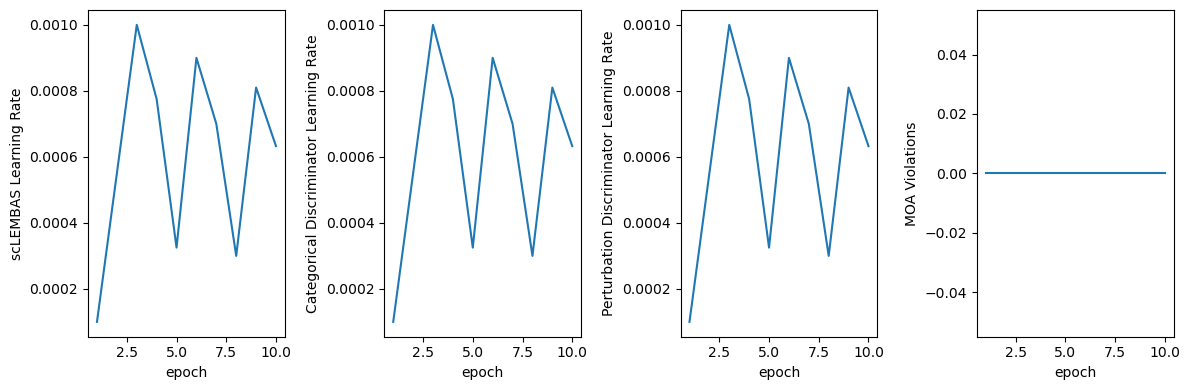

In [97]:
if visualize:
    fig, ax = plt.subplots(ncols = 4, figsize = (12, 4))

    sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
    ax[0].set_ylabel('scLEMBAS Learning Rate')

    sns.lineplot(data = train_stats_df, x = 'epoch', y = 'cat_discriminator_learning_rate', ax = ax[1])
    ax[1].set_ylabel('Categorical Discriminator Learning Rate')
    
    sns.lineplot(data = train_stats_df, x = 'epoch', y = 'pert_discriminator_learning_rate', ax = ax[2])
    ax[2].set_ylabel('Perturbation Discriminator Learning Rate')

    sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[3])
    ax[3].set_ylabel('MOA Violations')

    fig.tight_layout()
    # plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_epochs' + '.png'), dpi=300, bbox_inches='tight')


/tmp/ipykernel_547176/2505041036.py:41: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
/tmp/ipykernel_547176/2505041036.py:51: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
/tmp/ipykernel_547176/2505041036.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zeros = viz_df.groupby('loss_type').loss.apply(lambda x: (x == 0).all())
/tmp/ipykernel_547176/2505041036.py:120: UserWarning: The figure layout has changed to tight
  fig.tight_layout()  # reserve space at bottom


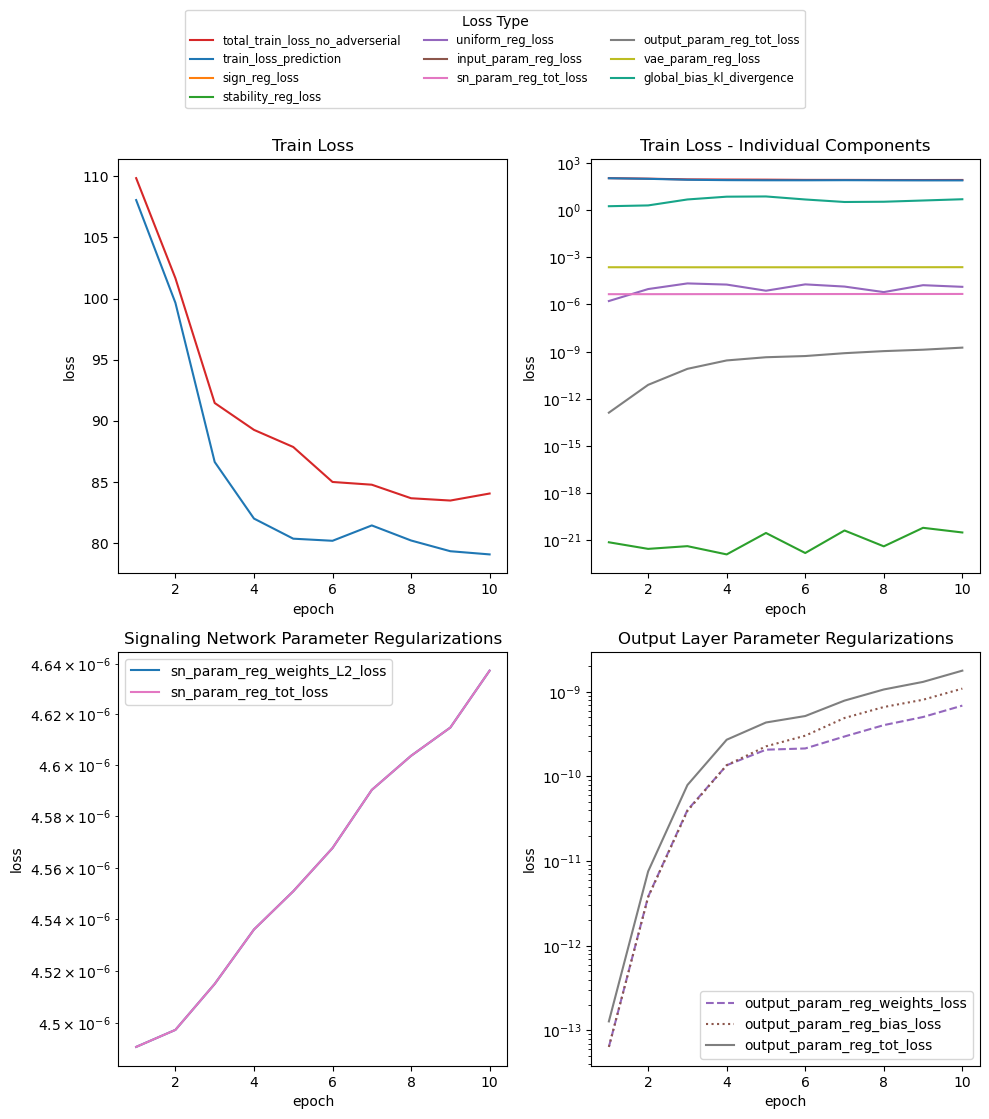

In [99]:
if visualize: 
    fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10, 10), 
                            constrained_layout=True)
    ax = axes.flatten()

    colors = [
        "#d62728",  # Red
        "#1f77b4",  # Blue
        "#ff7f0e",  # Orange
        "#2ca02c",  # Green
        "#9467bd",  # Purple
        "#8c564b",  # Brown
        "#e377c2",  # Pink
        "#7f7f7f",  # Gray
        "#bcbd22",  # Olive
        "#17a589",  #  Teal 
        "#6baed6",  # light blue
        "#ff9896"   # Light red
    ]
    palette = sns.color_palette(colors)

    # prediction loss
    i = 0

    loss_cols_main = [
           'train_loss_prediction', 'sign_reg_loss',
           'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
           'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
        'global_bias_kl_divergence']


    viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
    viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, 
                                      categories=['total_train_loss_no_adverserial'] + loss_cols_main)
    viz_df_all = viz_df.copy()
    viz_df = viz_df[viz_df.loss_type.isin(['train_loss_prediction', 'total_train_loss_no_adverserial'])]
    viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()

    sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
    ax[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.1), ncol = 3, fontsize = 'small')
    ax[i].set_title('Train Loss')
    ax[i].legend().remove()

    # all losses
    i = 1
    viz_df = viz_df_all.copy()
    del viz_df_all

    sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
    # ax[i].legend(loc='lower center', bbox_to_anchor=(-0.5, 1.1), ncol = 3, fontsize = 'small')
    handles_1, labels_1 = ax[i].get_legend_handles_labels()
    ax[i].legend().set_visible(False)
    ax[i].set_title('Train Loss - Individual Components')
    ax[i].set_yscale('log')


    # component losses
    i = 2


    loss_cols = sn_param_loss_cols + ['sn_param_reg_tot_loss']
    palette = ['tab:blue', 'tab:red', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
               (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)]


    # linestyles = ['--', '-.', 'dotted', 'solid']
    # linestyles = dict(zip(loss_cols, linestyles))

    viz_df = train_stats_df[['epoch'] + loss_cols].copy()
    viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

    zeros = viz_df.groupby('loss_type').loss.apply(lambda x: (x == 0).all())
    zeros = np.array(zeros.index)[np.where(zeros)]
    viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
    viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
    palette = [col for i,col in enumerate(palette) if loss_cols[i] in viz_df.loss_type.cat.categories]
    palette = dict(zip(viz_df.loss_type.cat.categories, palette))

    for lt in viz_df.loss_type.cat.categories:
        viz_df_ = viz_df[viz_df.loss_type == lt]
        sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                     color = palette[lt], # linestyle = linestyles[lt],
                     ax = ax[i])
    ax[i].set_title('Signaling Network Parameter Regularizations')
    ax[i].set_yscale('log')
    # legend_handles = [Line2D([0], [0], color=palette[lt],linestyle=linestyles[lt], label=lt) for lt in loss_cols]
    legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]

    ax[i].legend(handles=legend_handles, loc = 'best')

    i = 3
    loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
    palette = ['tab:purple', 'tab:brown', 
               (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
    linestyles = ['--', 'dotted', 'solid']
    palette = dict(zip(loss_cols, palette))
    linestyles = dict(zip(loss_cols, linestyles))

    viz_df = train_stats_df[['epoch'] + loss_cols].copy()
    viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

    for lt in loss_cols:
        viz_df_ = viz_df[viz_df.loss_type == lt]
        sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                     color = palette[lt], linestyle = linestyles[lt],
                     ax = ax[i])
    ax[i].set_title('Output Layer Parameter Regularizations')
    ax[i].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=palette[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols]
    ax[i].legend(handles=legend_handles, loc = 'best')

    fig.legend(handles_1, labels_1,
               loc='lower center', bbox_to_anchor=(0.5, 1.01), 
               ncol=3, fontsize='small', title='Loss Type')

    fig.tight_layout()  # reserve space at bottom
    # plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_all' + '.png'), dpi=300, bbox_inches='tight')



# 5. Bias Adverserial Assessment

/tmp/ipykernel_547176/2080607018.py:47: UserWarning: The palette list has more values (12) than needed (7), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])


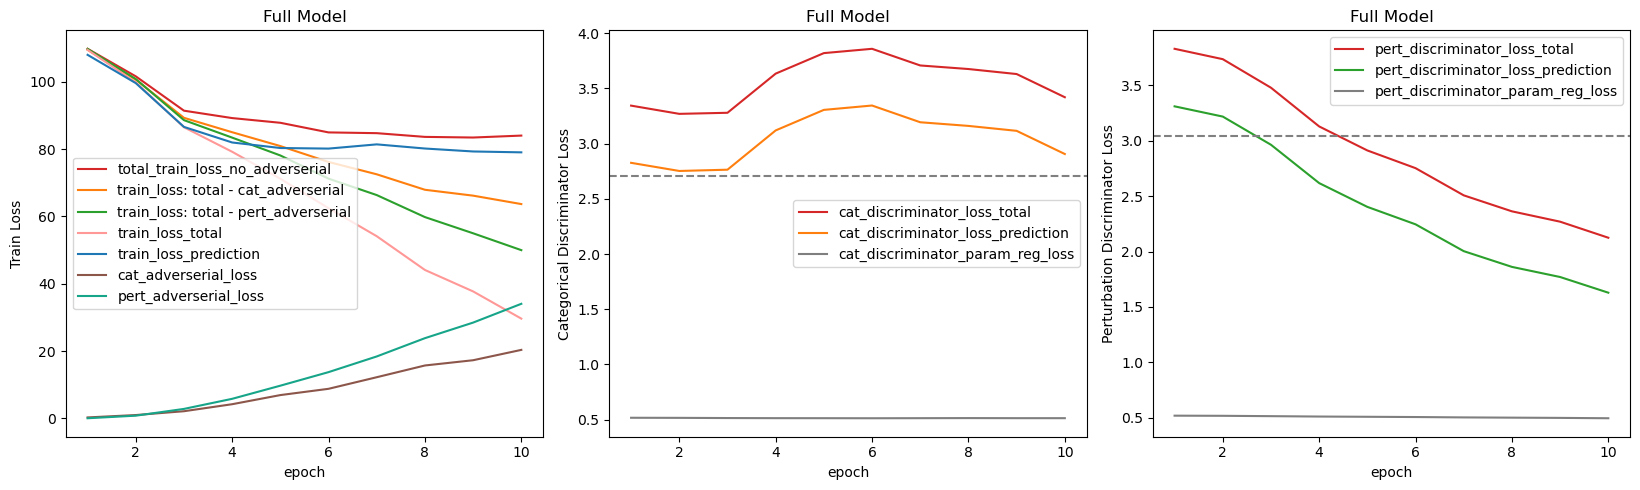

In [100]:
if visualize: 
    fig, ax = plt.subplots(ncols = 3, figsize = (16.5,5))
    ax = ax.flatten()

    colors = [
        "#d62728",  # Red
        "#ff7f0e",  # Orange
        "#2ca02c",  # Green
        "#ff9896",   # Light red
        "#1f77b4",  # Blue
        "#8c564b",  # Brown
        "#17a589",  #  Teal 
        "#bcbd22",  # Olive
        "#9467bd",  # Purple
        "#e377c2",  # Pink
        "#7f7f7f",  # Gray
        "#6baed6",  # light blue

    ]
    palette = sns.color_palette(colors)


    # Plot 1: full model, adverserial loss
    loss_cols_main = ['sign_reg_loss',
           'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
           'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
        'global_bias_kl_divergence']
    loss_cols = ['train_loss_total'] + loss_cols_main + ['cat_adverserial_loss', 'pert_adverserial_loss', 'train_loss_prediction']

    viz_df = train_stats_df[['epoch'] + loss_cols].copy()
    viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main + ['train_loss_prediction']].sum(axis = 1)
    
    viz_df.drop(columns = loss_cols_main, inplace = True)
    viz_df['train_loss: total - cat_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss
    viz_df['train_loss: total - pert_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.pert_adverserial_loss
    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_train_loss_no_adverserial',
                                                                                    'train_loss: total - cat_adverserial', 
                                                                                    'train_loss: total - pert_adverserial',
                                                                                    'train_loss_total', 
                                                                                    'train_loss_prediction',
                                                                                    'cat_adverserial_loss',
                                                                                   'pert_adverserial_loss'])



    sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
    ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
    ax[0].set_ylabel('Train Loss')
    ax[0].set_title('Full Model')

    # Plot 2: full model, categorical discriminator loss
    loss_cols_disc = ['cat_discriminator_loss_total',
           'cat_discriminator_loss_prediction', 'cat_discriminator_param_reg_loss']

    viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

    sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
                 palette = [palette[0], palette[1], palette[-2]], ax = ax[1])
    n_cat = trainer.cat_discriminator['discriminators']['celltype'].n_labels
    ax[1].axhline(y=np.log(n_cat), color='gray', linestyle='--')

    ax[1].legend(loc='best')
    ax[1].set_ylabel('Categorical Discriminator Loss')
    ax[1].set_title('Full Model')
    
    # Plot 3: full model, perturbation discriminator loss
    loss_cols_disc = ['pert_discriminator_loss_total',
           'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']

    viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
    viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

    sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
                 palette = [palette[0], palette[2], palette[-2]], ax = ax[2])
    n_cat = trainer.pert_discriminator['discriminator'].n_labels
    ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

    ax[2].legend(loc='best')
    ax[2].set_ylabel('Perturbation Discriminator Loss')
    ax[2].set_title('Full Model')


    fig.tight_layout()
    # plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
    ;



In [ ]:
cf_map = {'in_distribution': train_cells}
counterfactual_types = list(cf_map.keys()) + ['opposite']

## 5.1 Test Biases

In [ ]:
biases_res = {}
for counterfactual_type in ['opposite']:#, 'in_distribution']:
    biases_res[counterfactual_type] = {}
    biases = get_prediction(mod = mod, 
                            tf_adata = tf_adata, 
                            counterfactual_type = counterfactual_type, 
                            cf_map = cf_map, 
                            train_cells_all = train_cells, 
                            test_conds = test_conds, 
                            return_bias = True, 
                           train_mode = False)
    bias_global, bias_mu, bias_sigma, bias_cats, bias_tot, obs = biases
    
    biases_res[counterfactual_type]['adverserial'] = (bias_global, bias_mu, bias_sigma, bias_cats, bias_tot)
    biases_res[counterfactual_type]['obs'] = obs
    del biases
    torch.cuda.empty_cache()

The categorical embeddings has a few different visualizations: We show all the learned embeddings (Everything - Unweighted), those cell types that fell into the test conditions (Test - Unweighted), and those that did not fall into the test conditions (Train - Unweighted). It is important to keep in mind since this isn't a condition (stimulation x cell type combination), the embeddings categorized as test were seen and learned during training. Finally, we get the embedding outputs from running the forward prediction. This is simply taking each learned embedding, and repeating it as the same number of times as there are test cells for a given condition. It is essentially the same as Test - Unweighted, but now it is weighted by the number of cells predicted in each test condition cell type.

In [ ]:
if visualize:
    fig, axes = plt.subplots(ncols = 5, nrows = 1, figsize = (25, 5))
    ax = axes.flatten()

    np.random.seed(seed_split)

    i = 0
    # weights = mod.signaling_network.weights.detach().cpu().numpy().flatten()
    # weights = weights[weights != 0]
    weights = mod.signaling_network.weights[~mod.signaling_network.mask].detach().cpu().numpy()
    mean, std = np.mean(weights), np.std(weights)
    print('Weights: N({:.4f}, {:.4f})'.format(mean, std))
    if 'signaling_weights_scaler' in mod.signaling_network.bionet_params:
        weights *= mod.signaling_network.bionet_params['signaling_weights_scaler']
    weights = np.random.choice(weights, 5000, replace = False)

    counts, bins = np.histogram(weights, bins=30, density=True)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    # hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
    #           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
    sns.kdeplot(weights, ax = ax[i], 
                color = 'black', linestyle = '-', 
                label = 'Sample KDE')
    ax[i].set_xlabel('Trained Bionet Weights')

    x = np.linspace(-4, 4, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                      linestyle = '--', label='Sample Normal Distribution')

    # ax[i].legend()
    # ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
    #             loc='upper left', bbox_to_anchor=(-0.7, 1))

    i = 1
    bias = bias_tot.detach().cpu().numpy().flatten()
    mean, std = np.mean(bias), np.std(bias)
    print('Total Bias: N({:.4f}, {:.4f})'.format(mean, std))
    bias = np.random.choice(bias, 5000, replace = False)

    # counts, bins = np.histogram(bias, bins=30, density=True)
    # bin_centers = 0.5 * (bins[1:] + bins[:-1])
    # hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
    #           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
    # sns.kdeplot(bias, ax = ax[i], color = 'gray', linestyle = '--', label = 'Sample KDE', zorder = 0)
    sns.kdeplot(bias, ax = ax[i], 
                color = 'black', linestyle = '-', 
                label = 'Sample KDE')
    ax[i].set_xlabel('Trained Total Bias')

    x = np.linspace(-4, 4, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                      linestyle = '--', label='Sample Normal Distribution')

    ax[i].set_xlabel('Trained Total Bias')
    ax[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)


    i = 2
    bias = bias_global.detach().cpu().numpy().flatten()
    mean, std = np.mean(bias), np.std(bias)
    print('Global Bias: N({:.4f}, {:.4f})'.format(mean, std))
    bias = np.random.choice(bias, 5000, replace = False)

    # counts, bins = np.histogram(bias, bins=30, density=True)
    # bin_centers = 0.5 * (bins[1:] + bins[:-1])
    # hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
    #           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
    # sns.kdeplot(bias, ax = ax[i], color = 'gray', linestyle = '--', label = 'Sample KDE', zorder = 0)
    sns.kdeplot(bias, ax = ax[i], 
                color = 'black', linestyle = '-', 
                label = 'Sample KDE')
    ax[i].set_xlabel('Trained Bionet bias')

    x = np.linspace(-4, 4, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                      linestyle = '--', label='Sample Normal Distribution')

    ax[i].set_xlabel('Trained Global Bias')
    # ax[i].legend(loc='upper left', bbox_to_anchor=(1.05, 1))

    i = 3
    bias = bias_cats.detach().cpu().numpy().flatten()
    mean, std = np.mean(bias), np.std(bias)
    bias = np.random.choice(bias, 5000, replace = False)

    # counts, bins = np.histogram(bias, bins=30, density=True)
    # bin_centers = 0.5 * (bins[1:] + bins[:-1])
    # hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
    #           color=sns.color_palette()[0], edgecolor = 'black', label="Sample Histogram")
    # sns.kdeplot(bias, ax = ax[i], color = 'gray', linestyle = '--', label = 'Sample KDE', zorder = 0)
    sns.kdeplot(bias, ax = ax[i], 
                color = 'black', linestyle = '-', 
                label = 'Sample KDE')
    ax[i].set_xlabel('Trained Categorical Bias (Predicted - Weighted Test)')

    x = np.linspace(-4, 4, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x), color = 'green', linestyle = '--', label="Standard Normal")

    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    _, = ax[i].plot(x, stats.norm.pdf(x, loc=mean, scale=std), color = 'red', 
                      linestyle = '--', label='Sample Normal Distribution')

    ax[i].set_xlabel('Trained Categorical Bias')

    i = 4
    bias = bias_cats.detach().cpu().numpy().flatten()
    bias_cat_embeddings = mod.signaling_network.cat_embeddings.seurat_annotations.weight.detach().cpu().numpy()

    test_ct_idx = [mod.signaling_network.cat_mapper['celltype'][ct.split('^')[1]] for ct in test_conds]
    bias_cat_test = bias_cat_embeddings[test_ct_idx,:].flatten()

    train_ct_idx = sorted(set(mod.signaling_network.cat_mapper['celltype'].values()).difference(test_ct_idx))
    bias_cat_train = bias_cat_embeddings[train_ct_idx,:].flatten()

    bias_cat_embeddings = bias_cat_embeddings.flatten()

    cmd = 'Categorical Bias: Predicted (Weighted Test) | Test (Unweighted) | Train (Unweighted) | Everything (Unweighted): '
    cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias), np.std(bias))
    cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias_cat_test), np.std(bias_cat_test))
    cmd += 'N({:.4f}, {:.4f}) | '.format(np.mean(bias_cat_train), np.std(bias_cat_train))
    cmd += 'N({:.4f}, {:.4f})'.format(np.mean(bias_cat_embeddings), np.std(bias_cat_embeddings))
    print(cmd)

    sns.kdeplot(np.random.choice(bias, 5000, replace = False), 
                ax = ax[i], color = 'blue', label = 'Predicted (Weighted Test)')
    sns.kdeplot(bias_cat_test, 
                ax = ax[i], color = 'red', label = 'Test (Unweighted)')
    sns.kdeplot(bias_cat_train, 
                ax = ax[i], color = 'green', label = 'Train (Unweighted)')
    sns.kdeplot(bias_cat_embeddings, 
                ax = ax[i], color = 'black', label = 'Everything (Unweighted)')
    ax[i].legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)

    ax[i].set_xlabel('Trained Categorical Biases')

    fig.tight_layout()
    # plt.savefig(os.path.join(data_path, 'trash', fn + '_bias_dist' + '.png'), dpi=300, bbox_inches='tight')
    ;

Run the embedding:

We will visualize both the UMAP and PCA space to see whether linear and non-linear mixing is being captured.

In [ ]:
if run_type == 'E': # nothing to do with just one test condition
    if bias_global.shape[0] < 50:
        n_components = 10
    else:
        n_components = 50

    biases_clustered = {}
    for counterfactual_type, br in biases_res.items():
        print(counterfactual_type)
        bias_global, _, _, bias_cats, bias_tot = br['adverserial']
        obs = br['obs']

        # full model
        bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
        embed_tf_activity(bias_global, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1,
                         n_components = n_components)

        # full model -- categorical information added
        bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
        embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1,
                         n_components = n_components)

        # full model -- categorical information only
        bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
        embed_tf_activity(bias_cats, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                         n_components = n_components)

        biases_clustered[counterfactual_type] = (bias_global, bias_tot, bias_cats)

    io.write_pickled_object(biases_clustered,  
                            os.path.join(data_path, 'trash', fn + '_feb_clustered_biases.pickle'))

In [ ]:
if visualize and run_type == 'E':
    biases_clustered = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases.pickle'))

    bias_global, bias_tot, bias_cats = biases_clustered[counterfactual_type]
    bias_types = {'Global': bias_global, 
                 'Categorical': bias_cats, 
                 'Total': bias_tot}

    cat_map = {'seurat_annotations': 'Cell Type', 
              'stim': 'Stimulation'}
    
    ncols = len(bias_types)
    nrows = len(cat_map)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

    subset_size = None
    for j, (bias_type, bias) in enumerate(bias_types.items()):
        for i, cat in enumerate(['seurat_annotations', 'stim']):
            viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                            reduction_type = 'umap', 
                                            cat = cat,
                                            subset_size = subset_size)


            sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
                            s=10,
                            ax = ax[i,j])
            ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                            xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
            ax[i,j].set_title(bias_type + ' Bias')

        


In [ ]:
if visualize and run_type == 'E':
    
    biases_clustered = io.read_pickled_object(os.path.join(data_path, 
                                                           'trash', fn + '_feb_clustered_biases.pickle'))
    bias_global, bias_tot, bias_cats = biases_clustered[counterfactual_type]
    bias_types = {'Global': bias_global, 
                 'Categorical': bias_cats, 
                 'Total': bias_tot}

    cat_map = {'seurat_annotations': 'Cell Type', 
              'stim': 'Stimulation'}
    

    ncols = len(bias_types)
    nrows = len(cat_map)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

    subset_size = None
    for j, (bias_type, bias) in enumerate(bias_types.items()):
        for i, cat in enumerate(['seurat_annotations', 'stim']):
            viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                            reduction_type = 'pca', 
                                            cat = cat,
                                            subset_size = subset_size)


            sns.scatterplot(data = viz_df, x = 'PC1', y = 'PC2', hue = cat, 
                            s=10,
                            ax = ax[i,j])
            ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                            xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
            ax[i,j].set_title(bias_type + ' Bias')

        


## 5.2: Train Biases

This is visualized to see that train matchest test. Furthermore, in LOO test conditions, the visualizations aren't informative because there are no conditions to check for mixing. 

In [ ]:
# split for CUDA memory
def split_list(lst, n):
    k, m = divmod(len(lst), n)
    return [lst[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n)]

n_chunks = 5
train_cell_chunks = split_list(train_cells, n_chunks)


# get biases
bias_global_train, bias_cats_train, bias_tot_train, obs_train = [], [], [], []
for tcc in train_cell_chunks:
    biases_chunk = get_prediction(mod = mod, 
                            tf_adata = tf_adata[tcc, :], 
                            counterfactual_type = None, 
                            cf_map = None, 
                            train_cells_all = tcc, 
                            test_conds = None, 
                            remove_type = 'none',
                            return_bias = True, 
#                             return_loss = None, 
                            test_cells = None, 
                            train_mode = True
                                                 ) 
    bias_global_train_chunk, _, _, bias_cats_train_chunk, bias_tot_train_chunk, obs_train_chunk = biases_chunk
    bias_global_train.append(bias_global_train_chunk)
    bias_cats_train.append(bias_cats_train_chunk)
    bias_tot_train.append(bias_tot_train_chunk)
    obs_train.append(obs_train_chunk)
        
obs_train = pd.concat(obs_train, axis=0)
bias_global_train = torch.cat(bias_global_train, dim=0)
bias_cats_train = torch.cat(bias_cats_train, dim = 1)
bias_tot_train = torch.cat(bias_tot_train, dim = 1)

# format
counterfactual_type = 'opposite'
biases_res_train = {}
biases_res_train[counterfactual_type] = {}
biases_res_train[counterfactual_type]['adverserial'] = (bias_global_train, bias_cats_train, bias_tot_train)
biases_res_train[counterfactual_type]['obs'] = obs_train


# run embedding
if bias_global_train.shape[0] < 50:
    n_components = 10
else:
    n_components = 50

biases_clustered = {}

for counterfactual_type, br in biases_res_train.items():
    bias_global, bias_cats, bias_tot = br['adverserial']
    obs = br['obs']

    # full model
    bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
    embed_tf_activity(bias_global, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)

    # full model -- categorical information added
    bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
    embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)

    # full model -- categorical information only
    bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
    embed_tf_activity(bias_cats, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                     n_components = n_components)

    biases_clustered[counterfactual_type] = (bias_global, bias_tot, bias_cats)

io.write_pickled_object(biases_clustered,  
                        os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))

In [ ]:
bias_train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))
if not bias_train_pred:
    print('We do not have training predictions for bias')
else: 
    biases_clustered_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases_train.pickle'))


In [ ]:
if visualize and bias_train_pred:
    bias_global, bias_tot, bias_cats = biases_clustered_train[counterfactual_type]
    bias_types = {'Global': bias_global, 
                 'Categorical': bias_cats, 
                 'Total': bias_tot}

    cat_map = {'seurat_annotations': 'Cell Type', 
              'stim': 'Stimulation'}

    ncols = len(bias_types)
    nrows = len(cat_map)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

    subset_size = 5000 if bias_global.shape[0] > 5000 else None
    for j, (bias_type, bias) in enumerate(bias_types.items()):
        for i, cat in enumerate(['seurat_annotations', 'stim']):
            viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                            reduction_type = 'umap', 
                                            cat = cat,
                                            subset_size = subset_size)


            sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
                            s=10,
                            ax = ax[i,j])
            ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                            xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
            ax[i,j].set_title(bias_type + ' Bias')

            if cat == 'seurat_annotations':
                ax[i,j].legend().set_visible(False)

In [ ]:
if visualize and bias_train_pred:
    bias_global, bias_tot, bias_cats = biases_clustered_train[counterfactual_type]
    bias_types = {'Global': bias_global, 
                 'Categorical': bias_cats, 
                 'Total': bias_tot}

    cat_map = {'seurat_annotations': 'Cell Type', 
              'stim': 'Stimulation'}

    ncols = len(bias_types)
    nrows = len(cat_map)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

    subset_size = 5000 if bias_global.shape[0] > 5000 else None
    for j, (bias_type, bias) in enumerate(bias_types.items()):
        for i, cat in enumerate(['seurat_annotations', 'stim']):
            viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                            reduction_type = 'pca', 
                                            cat = cat,
                                            subset_size = subset_size)


            sns.scatterplot(data = viz_df, x = 'PC1', y = 'PC2', hue = cat, 
                            s=10,
                            ax = ax[i,j])
            ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                            xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
            ax[i,j].set_title(bias_type + ' Bias')

            if cat == 'seurat_annotations':
                ax[i,j].legend().set_visible(False)

# 6. Get the predictions

In [ ]:
best_resolution = tf_adata.uns['leiden']['params']['resolution']
calculation_type = 'project' # project data rather than embed
n_neighbors = 15
run_umap = True

In [ ]:
cf_map = {'in_distribution': train_cells}
counterfactual_types = list(cf_map.keys()) + ['opposite']

counterfactual_type = 'opposite'
remove_components = ['none', 
                         ['adj', 'categorical_bias'], 
                         ['adj', 'global_bias'],
                         'total_bias', 'adj',
                         'categorical_bias',
                         'global_bias']

## 6A: Train Predictions

This will help elucidate whether any issues we encounter are structural (problem with the model) or overfitting on the training data

In [ ]:
def split_list(lst, n):
    k, m = divmod(len(lst), n)
    return [lst[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n)]

n_chunks = 5
train_cell_chunks = split_list(train_cells, n_chunks)

In [ ]:
counter = 0

tf_res = {}
for remove_type in tqdm(remove_components):
#     tf_adata_predicted, tot_loss = get_prediction(mod = mod, 
#                                                   tf_adata = tf_adata, 
#                                                   counterfactual_type = None, 
#                                                   cf_map = None, 
#                                                   train_cells_all = train_cells, 
#                                                   test_conds = None, 
#                                                   remove_type = remove_type,
#                                                   return_bias = None, 
#                                                   return_loss = True, 
#                                                  test_cells = None, 
#                                                   train_mode = True
#                                                  ) 
    # separate prediction into "chunks"  for cuda memory
    tapc = []
    for tcc in train_cell_chunks:
        tf_adata_predicted = get_prediction(mod = mod, 
                                                      tf_adata = tf_adata[tcc, :], 
                                                      counterfactual_type = None, 
                                                      cf_map = None, 
                                                      train_cells_all = tcc, 
                                                      test_conds = None, 
                                                      remove_type = remove_type,
                                                      return_bias = None, 
#                                                       return_loss = True, 
                                                     test_cells = None, 
                                                      train_mode = True
                                                     ) 
        tapc.append(tf_adata_predicted)

    tf_adata_predicted = sc.concat(tapc)
    tf_adata_predicted.obs_names_make_unique()

    if type(remove_type) == list:
        remove_type = '_'.join(remove_type)


    run_umap = True if remove_type == 'none' else False # for visualization
    tf_adata_predicted = prepare_for_metrics(tf_adata, 
                                             tf_adata_predicted, 
                                             resolution = best_resolution,
                                             calculation_type = calculation_type, 
                                             n_neighbors = n_neighbors, 
                                             run_umap = run_umap
                                            )
    tf_res[remove_type] = tf_adata_predicted

io.write_pickled_object(tf_res, 
                       os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))

clear_memory()



## 6B: Test Predictions

In [ ]:
counter = 0

tf_res = {}
for remove_type in tqdm(remove_components):
    tf_adata_predicted = get_prediction(mod = mod, 
                                                  tf_adata = tf_adata, 
                                                  counterfactual_type = counterfactual_type, 
                                                  cf_map = cf_map, 
                                                  train_cells_all = train_cells, 
                                                  test_conds = test_conds, 
                                                  remove_type = remove_type,
                                                  return_bias = False, 
#                                                   return_loss = True, 
                                                 test_cells = test_cells, 
                                                  train_mode = False
                                                 ) 
    if type(remove_type) == list:
        remove_type = '_'.join(remove_type)

    run_umap = True if remove_type == 'none' else False # for visualization
    tf_adata_predicted = prepare_for_metrics(tf_adata, 
                                             tf_adata_predicted, 
                                             resolution = best_resolution,
                                             calculation_type = calculation_type, 
                                             n_neighbors = n_neighbors, 
                                             run_umap = run_umap
                                            )
    tf_res[remove_type] = tf_adata_predicted


io.write_pickled_object(tf_res, 
                       os.path.join(data_path, 'trash', fn + '_predictions.pickle'))

clear_memory()



Get the loss from the predictions:

In [ ]:
# test
tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))

loss_res = []
for remove_type, tf_adata_predicted in tf_res.items():
    loss = get_loss(tf_adata, tf_adata_predicted[tf_adata_predicted.obs.batch == 'predicted', ])
    loss = pd.DataFrame(loss, index = [0])
    loss['Removed Model Component'] = remove_type
#     loss['prediction_type'] = 'test'
    loss_res.append(loss)
loss_res = pd.concat(loss_res, axis = 0).reset_index(drop = True)
loss_res.to_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss.csv'))

# train
train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
if train_pred:
    tf_res_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
    loss_res = []
    for remove_type, tf_adata_predicted in tqdm(tf_res_train.items()):
        loss = get_loss(tf_adata, tf_adata_predicted[tf_adata_predicted.obs.batch == 'predicted', ])
        loss = pd.DataFrame(loss, index = [0])
        loss['Removed Model Component'] = remove_type
    #     loss['prediction_type'] = 'train'
        loss_res.append(loss)
    loss_res = pd.concat(loss_res, axis = 0).reset_index(drop = True)
    loss_res.to_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss_train.csv'))

    
    


In [ ]:
train_pred = os.path.isfile(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
    
if train_pred:
    tf_res_train = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))
    loss_res_train = pd.read_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss_train.csv'), 
                      index_col = 0)
else:
    print('We do not have train predictions')
    tf_res_train, loss_res_train = None, None

tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
loss_res = pd.read_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss.csv'), 
                      index_col = 0)

loss_res_map = {'train': loss_res_train, 'test': loss_res}

# 7. Visualize Predictions

# 7.1 Visualize loss of each component:

## Total Loss

In [ ]:
if visualize:
    ncols = len(loss_res_map)
    fig, ax = plt.subplots(ncols = ncols, figsize = (ncols*5.1, 5))


    xtick_map = {'none': 'Full Model', 
     'adj': 'Adjacency Matrix', 
     'total_bias': 'Total Bias', 
    'categorical_bias': 'Categorical Bias', 
    'global_bias': 'Global Bias', 
                'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
                'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}


    for i, (prediction_type, loss_res) in enumerate(loss_res_map.items()):
        if loss_res is not None:

            viz_df = loss_res.copy()
            viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

            sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = 'EMD Loss', ax = ax[i])

            for x, y in zip(viz_df['Removed Model Component'], viz_df['EMD Loss']):
                ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
            ax[i].axhline(y=0, color='black')
            ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model']['EMD Loss'], 
                       color='red', linestyle = '--')

            ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')

        ax[i].set_title(prediction_type + ' | ' + counterfactual_type)

    fig.tight_layout()
    ;



## Individual conditions

In [ ]:
if visualize:
    prediction_type = 'test'
    loss_res = loss_res_map[prediction_type]
    
    conds = list(set(loss_res.columns).difference(['Removed Model Component', 'EMD Loss']))
    conds_ = pd.Series(conds).str.split('^', expand=True)
    conds_['combined'] = conds
    conds = conds_.sort_values(by=[1,0]).combined.tolist()
    
    ncols = min(len(conds), 7)
    nrows = math.ceil(len(conds)/ncols)

    if len(conds) == 1:
        print('Test individual condition is same as above full test for LOO')
    else:
        fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols*5.1, nrows*5))
        if isinstance(axes, np.ndarray):
            ax = axes.flatten()
        else:
            ax = [axes]

        xtick_map = {'none': 'Full Model', 
         'adj': 'Adjacency Matrix', 
         'total_bias': 'Total Bias', 
        'categorical_bias': 'Categorical Bias', 
        'global_bias': 'Global Bias', 
                    'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
                    'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}

        for i, cond in enumerate(conds):
            viz_df = loss_res.copy()
            viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

            sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = cond, ax = ax[i])

            for x, y in zip(viz_df['Removed Model Component'], viz_df[cond]):
                ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
            ax[i].axhline(y=0, color='black')
            ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model'][cond], 
                       color='red', linestyle = '--')

            ax[i].set_xticks(ax[i].get_xticks())  
            ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')
            ax[i].set_title(cond)

        fig.suptitle(prediction_type)
        fig.tight_layout()
        ;    

In [ ]:
if visualize and train_pred:
    prediction_type = 'train'
    loss_res = loss_res_map[prediction_type]

    conds = list(set(loss_res.columns).difference(['Removed Model Component', 'EMD Loss']))
    conds_ = pd.Series(conds).str.split('^', expand=True)
    conds_['combined'] = conds
    conds = conds_.sort_values(by=[1,0]).combined.tolist()
    
    ncols = min(len(conds), 7)
    nrows = math.ceil(len(conds)/ncols)

    fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols*5.1, nrows*5))
    if isinstance(axes, np.ndarray):
        ax = axes.flatten()
    else:
        ax = [axes]

    xtick_map = {'none': 'Full Model', 
     'adj': 'Adjacency Matrix', 
     'total_bias': 'Total Bias', 
    'categorical_bias': 'Categorical Bias', 
    'global_bias': 'Global Bias', 
                'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
                'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}

    for i, cond in enumerate(conds):
        viz_df = loss_res.copy()
        viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

        sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = cond, ax = ax[i])

        for x, y in zip(viz_df['Removed Model Component'], viz_df[cond]):
            ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
        ax[i].axhline(y=0, color='black')
        ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model'][cond], 
                   color='red', linestyle = '--')

        ax[i].set_xticks(ax[i].get_xticks())  
        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')
        ax[i].set_title(cond)

    fig.suptitle(prediction_type)
    fig.tight_layout()
    ;    

## 7.2 Visualize first 2 PCs of each model component

The title indicates which component was removed (e.g., if "total_bias" is shown, that was removed, and predictions were run only using the adjacency matrix).

### Full TF PC space of actual data

This visualization provides a reference for the global distribution of cell types/stimulation when looking at teh specific ones below. We can see that stimulation provides strong separation. 

In [ ]:
if visualize: 
    fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

    tf_adata_viz = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations',  'stim'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                     seed = seed_split)
    viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)

    marker_dict = {'CTRL': 'o', 'STIM': '^'}  

    i = 0
    sns.scatterplot(data = viz_df,
                    x = 'PC1', y = 'PC2', hue = 'seurat_annotations',
                    s = 10, 
    #                 style = 'stim', markers = marker_dict, s = 20,
                    ax = ax[i], legend = False)
    ax[i].set_title('Cell Type')

    i = 1
    sns.scatterplot(data = viz_df,
                    x = 'PC1', y = 'PC2', hue = 'stim',
                    s = 10, 
    #                 style = 'stim', markers = marker_dict, s = 20,
                    ax = ax[i])
    ax[i].set_title('Stimulation Condition')

    fig.tight_layout()
    ;

### Test

In [ ]:
tf_res_ = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))

In [ ]:
remove_components = ['none', 
                     ['adj', 'global_bias'],
                     'global_bias',
                     'total_bias',
                     ['adj', 'categorical_bias'],
                     'adj',
                     'categorical_bias']
# map to more inuitive title
remaining_components = ['Full Model', 'Categorical Bias Only', 
                        'Adj + Categorical Bias',
                       'Adjacency Matrix Only',  
                        'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
                       ]

cell_types = [tc.split('^')[1] for tc in test_conds]
nrows = len(test_conds)
ncols = len(remove_components)

counterfactual_type = 'opposite'


In [ ]:
remove_component = 'total_bias'
tf_res = tf_res_.copy()
tf_adata_all = tf_res[remove_component]
md = tf_adata_all.obs

md = md[md.batch == 'predicted']

stim_idx = md[md.stim == 'CTRL'].index.tolist()
print('Unstimulated (PC1, PC2) coordinates of A only prediction:')
print(np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, :2]))

stim_idx = md[md.stim == 'STIM'].index.tolist()
print('Stimulation (PC1, PC2) coordinates of A only prediction:')
print(np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, :2]))


In [ ]:
remaining_components = ['Full Model', 'Global Bias Only', 'Categorical Bias Only', 
                       'Adjacency Matrix Only', 'Total Bias', 'Adj + Global Bias', 
                       'Adj + Categorical Bias']

In [ ]:
if visualize: 
    fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])
    
    
    ax_top = axes[0,0]
    marker_dict = {'CTRL': 'o', 'STIM': '^'}  

    for j, remove_component in enumerate(remove_components):
        if type(remove_component) == list:
            remove_component = '_'.join(remove_component)
        tf_res = tf_res_.copy()
        tf_adata_all = tf_res[remove_component]

        tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

        tf_adata_viz = tf_adata_viz.copy()  
        tf_adata_viz.obs['condition'] = (
            tf_adata_viz.obs['sample'] + '^' + 
            tf_adata_viz.obs['celltype'] + '^' + 
            tf_adata_viz.obs['batch']
        )

        np.random.seed(seed)
        tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

        viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                         cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                         max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                         seed = seed_split)
        viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                                  categories = cell_types, ordered=True)
        viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)


        for i, cell_type in enumerate(cell_types):
            viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

            stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
            order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                    stim_pred + '^' + cell_type + '^' + 'actual', 
                    rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
            viz_df_ = viz_df_.copy()
            order_values = ['predicted', 'test', 'train']
            order_map = dict(zip(order, order_values))
            viz_df_['condition'] = viz_df_.condition.map(order_map)

            viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
                                                  categories = order_values, ordered=True)

            np.random.seed(seed_split)
            viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

            if i == 0 and j == 0:
                legend = True
            else: 
                legend = False

            if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:
                viz_df_1 = viz_df_[viz_df_.condition.isin(['test', 'train'])].copy()
                viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
                sns.scatterplot(data = viz_df_1, 
                                x = 'PC1', y = 'PC2', 
                                hue = 'condition', palette = sns.color_palette("deep")[1:3],
                                style = 'stim', markers = marker_dict, s = 20, 
                                ax = axes[i, j], legend = legend)

                viz_df_2 = viz_df_[viz_df_.condition == 'predicted']
                viz_df_2.condition.cat.remove_unused_categories()
                if not viz_df_2.PC1.nunique():
                    raise ValueError('Unexpected distribution in predicted values')
                else:
                    viz_df_2 = pd.DataFrame(viz_df_2.iloc[0, :]).T
                sns.scatterplot(data = viz_df_2, 
                                x = 'PC1', y = 'PC2', 
                                color = sns.color_palette("deep")[0],
                                marker = marker_dict[viz_df_2.stim.tolist()[0]], s = 100, 
                               ax = axes[i, j], legend = legend)

            else:
                sns.scatterplot(data = viz_df_, 
                                x = 'PC1', y = 'PC2', hue = 'condition', 
                                style = 'stim', markers = marker_dict, s = 20,
                                ax = axes[i, j], legend = legend)


            if legend:
                handles, labels = axes[i, j].get_legend_handles_labels()
                labels[1:4] = ['predicted', 'test', 'train']
                axes[i, j].legend(handles=handles, labels=labels)
            axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])


            if i == 0 and j == 0:
                legend_actual = axes[i,j].legend_  # Store the legend
                axes[i,j].legend_.remove() 

    fig.legend(handles=legend_actual.legendHandles,
               ncols = 2,
               labels=[t.get_text() for t in legend_actual.get_texts()], 
               loc="upper center", 
               fontsize = 15, 
               markerscale=2, 
               bbox_to_anchor=(0.5, 1.5),
               bbox_transform=ax_top.transAxes)
    fig.tight_layout()
    # plt.savefig('example.png', dpi=300, bbox_inches='tight')
    ;


### Train

In [ ]:
if train_pred:
    tf_res_ = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions_train.pickle'))


    remove_components = ['none', 
                         ['adj', 'global_bias'],
                         'global_bias',
                         'total_bias',
                         ['adj', 'categorical_bias'],
                         'adj',
                         'categorical_bias']
    # map to more inuitive title
    remaining_components = ['Full Model', 'Categorical Bias Only', 
                            'Adj + Categorical Bias',
                           'Adjacency Matrix Only',  
                            'Global Bias Only', 'Total Bias', 'Adj + Global Bias', 
                           ]
    train_conds = sorted(train_cond, key=lambda x: (x.split('^')[1], x.split('^')[0]))
    cell_types = sorted(set([tc.split('^')[1] for tc in train_conds]))
    nrows = len(train_conds)
    ncols = len(remove_components)

    counterfactual_type = 'opposite'

    remove_component = 'total_bias'
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[remove_component]
    md = tf_adata_all.obs

    md = md[md.batch == 'predicted']

    ctrl_idx = md[md.stim == 'CTRL'].index.tolist()
    ctrl_coords = np.unique(tf_adata_all[ctrl_idx, :].obsm['X_pca'][:, :2])
    print('Unstimulated (PC1, PC2) coordinates of A only prediction:')
    print(ctrl_coords)

    stim_idx = md[md.stim == 'STIM'].index.tolist()
    stim_coords = np.unique(tf_adata_all[stim_idx, :].obsm['X_pca'][:, :2])
    print('Stimulation (PC1, PC2) coordinates of A only prediction:')
    print(stim_coords)

    print('The shift in predictions of A only upon the introduction of stimulation is (PC1, PC2):')
    print(stim_coords - ctrl_coords)



In [ ]:
if visualize and train_pred: 
    fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
    ax_top = axes[0, 0]

    marker_dict = {'CTRL': 'o', 'STIM': '^'}  

    for j, remove_component in enumerate(remove_components):
        if type(remove_component) == list:
            remove_component = '_'.join(remove_component)
        tf_res = tf_res_.copy()
        tf_adata_all = tf_res[remove_component]

        tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

        tf_adata_viz = tf_adata_viz.copy()  
        tf_adata_viz.obs['condition'] = (
            tf_adata_viz.obs['sample'] + '^' + 
            tf_adata_viz.obs['celltype'] + '^' + 
            tf_adata_viz.obs['batch']
        )

        np.random.seed(seed)
        tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

        viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                         cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                         max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                         seed = seed_split)
        viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                                  categories = cell_types, ordered=True)
        viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)


    #     # alternative with fewer plots would be to still iterate
    #     # by cell type and color by batch and marker by stim (visualizing both predictions for a cell type in one plot)
    #     # this visualization gets tricky to see
    #     for i, cell_type in enumerate(cell_types):
    #         viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

    #         np.random.seed(seed_split)
    #         viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

    #         # no ordering by condition or remapping
    #         sns.scatterplot(data = viz_df_, 
    #                     x = 'PC1', y = 'PC2', 
    #                     hue = 'batch', 
    #                     style = 'stim', markers = marker_dict, s = 20,
    #                     ax = axes[i,j], legend = legend)


        for i, cond in enumerate(train_conds):
            stim_pred, cell_type = cond.split('^')

            viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]
            viz_df_ = viz_df_[((viz_df_.batch == 'predicted') & (viz_df_.stim == stim_pred)) |
                              (viz_df_.batch == 'actual')]

            order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                    stim_pred + '^' + cell_type + '^' + 'actual', 
                    rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
            viz_df_ = viz_df_.copy()
            order_values = ['predicted', 'test', 'train']
            order_map = dict(zip(order, order_values))
            viz_df_['condition'] = viz_df_.condition.map(order_map)

            viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
                                                  categories = order_values, ordered=True)

            np.random.seed(seed_split)
            viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

            if i == 0 and j == 0:
                legend = True
            else: 
                legend = False

            if remove_component in ['global_bias', 'total_bias', 'adj_global_bias']:
                viz_df_1 = viz_df_[viz_df_.condition.isin(['test', 'train'])].copy()
                viz_df_1.condition = viz_df_1.condition.cat.remove_unused_categories()
                sns.scatterplot(data = viz_df_1, 
                                x = 'PC1', y = 'PC2', 
                                hue = 'condition', palette = sns.color_palette("deep")[1:3],
                                style = 'stim', markers = marker_dict, s = 20, 
                                ax = axes[i, j], legend = legend)

                viz_df_2 = viz_df_[viz_df_.condition == 'predicted']
                viz_df_2.condition.cat.remove_unused_categories()
                if not viz_df_2.PC1.nunique():
                    raise ValueError('Unexpected distribution in predicted values')
                else:
                    viz_df_2 = pd.DataFrame(viz_df_2.iloc[0, :]).T
                sns.scatterplot(data = viz_df_2, 
                                x = 'PC1', y = 'PC2', 
                                color = sns.color_palette("deep")[0],
                                marker = marker_dict[viz_df_2.stim.tolist()[0]], s = 100, 
                               ax = axes[i, j], legend = legend)

            else:
                sns.scatterplot(data = viz_df_, 
                                x = 'PC1', y = 'PC2', hue = 'condition', 
                                style = 'stim', markers = marker_dict, s = 20,
                                ax = axes[i, j], legend = legend)


            if legend:
                handles, labels = axes[i, j].get_legend_handles_labels()
                labels[1:4] = ['predicted', 'test', 'train']
                axes[i, j].legend(handles=handles, labels=labels)
            axes[i,j].set_title(cell_type + ' | ' + remaining_components[j])


            if i == 0 and j == 0:
                legend_actual = axes[i,j].legend_  # Store the legend
                axes[i,j].legend_.remove() 

    fig.legend(handles=legend_actual.legendHandles,
               ncols = 2,
               labels=[t.get_text() for t in legend_actual.get_texts()], 
               loc="upper center", 
               fontsize = 15, 
               markerscale=2, 
               bbox_to_anchor=(0.5, 1.5),
               bbox_transform=ax_top.transAxes)
    fig.tight_layout()

    ;

## 7.3 Visualize first 3 PCs of full model

In [ ]:
tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
tf_adata_all = tf_res['none']

In [ ]:
n_pcs = 3

In [ ]:
if visualize: 
    marker_dict = {'CTRL': 'o', 'STIM': '^'}  


    pc_combs = list(itertools.combinations(range(1, n_pcs + 1), 2))

    ncols = len(test_conds)
    nrows = len(pc_combs)
    fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))
    if nrows == 1 and ncols == 1:
        ax = np.array([[ax]])
    elif nrows == 1:
        ax = np.array([ax])
    elif ncols == 1:
        ax = np.array([[a] for a in ax])


    cell_types = [tc.split('^')[1] for tc in test_conds]

    tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

    tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['sample'] + '^' + 
        tf_adata_viz.obs['celltype'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca', 
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 1000, 
                             seed = seed_split)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)
    viz_df.stim = pd.Categorical(viz_df.stim, categories = ['CTRL', 'STIM'], ordered = True)



    for j, cell_type in enumerate(cell_types):
        for i, comb in enumerate(pc_combs):
    #         print(comb)
            viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

            stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
            order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                    stim_pred + '^' + cell_type + '^' + 'actual', 
                    rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
            viz_df_ = viz_df_.copy()
            order_values = ['predicted', 'test', 'train']
            order_map = dict(zip(order, order_values))
            viz_df_['condition'] = viz_df_.condition.map(order_map)

            viz_df_['condition'] = pd.Categorical(viz_df_.condition, 
                                                  categories = order_values, ordered=True)

            np.random.seed(seed)
            viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]

            if not (i == 0 and j == 0):
                legend = False
            else:
                legend = True
            sns.scatterplot(data = viz_df_, 
                            x = 'PC{}'.format(comb[0]), 
                            y = 'PC{}'.format(comb[1]), 
                            hue = 'condition', 
                            style = 'stim', markers = marker_dict, s = 20,
                            ax = ax[i, j], legend = legend)


            if legend:
                handles, labels = ax[i, j].get_legend_handles_labels()
                labels[1:4] = ['predicted', 'test', 'train']
                ax[i, j].legend(handles=handles, labels=labels)

            ax[i,j].set_title(cell_type)

    # fig.text(0.5, title_coords[i], 
    #          counterfactual_type_title[counterfactual_type], 
    #          ha='center', va='center', fontsize=18, fontweight='bold')

    fig.tight_layout(rect=[0,0,1,0.9])


In [ ]:
clear_memory()

In [ ]:
import papermill as pm
from nbconvert import HTMLExporter
import nbformat
import os

input_notebook = 'visualize.ipynb' # in the current directory
output_notebook = os.path.join(data_path, 'trash', fn + '.ipynb')
output_html = os.path.join(data_path, 'trash', fn + '.html')

pm.execute_notebook(
    input_path=input_notebook,
    output_path=output_notebook,
    parameters={"fn": fn}, 
    kernel_name='python3'
)

nb = nbformat.read(output_notebook, as_version=4)
html_exporter = HTMLExporter()
(body, _) = html_exporter.from_notebook_node(nb)

with open(output_html, "w", encoding="utf-8") as f:
    f.write(body)
    
os.remove(output_notebook)

Clear variables:

In [ ]:
# Delete all user-defined variables
for name in dir():
    if not name.startswith("_"):
        if not name in ['In', 'Out', 'exit', 'get_ipython', 'open', 'quit']:
            del globals()[name]

